# Short-term Rainfall Forecasting: PurgedKFold on NOAA GHCN-Daily

## Domain context

Statistical weather forecasting leans on long historical records of daily station observations. NOAA's GHCN-Daily (Global Historical Climatology Network) database (Menne *et al.*, 2012) holds century-scale daily records of temperature, precipitation, wind, and pressure for tens of thousands of stations worldwide.

Build a rainfall model on this and temporal autocorrelation is unavoidable. Weather on day *t* is strongly tied to days *t-1* and *t+1* through simple persistence. Seasonality adds an annual echo: the atmosphere in June this year looks a lot like June last year. And the target itself, tomorrow's precipitation, is literally information from tomorrow, so putting tomorrow in train while today sits in test hands the model the answer.

`PurgedKFold` deals with this by holding out contiguous blocks of time as test folds and purging training rows whose 1-day label horizon overlaps the test period. A one-day embargo clears the nearest residual autocorrelation.

**Data source:** NOAA GHCN-Daily station USW00014732 (La Guardia Airport, New York City). Direct CSV download from NCEI, no credentials required.
URL: https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00014732.csv
License: U.S. Government public domain (NOAA/NCEI).

In [1]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import purgedcv
from purgedcv import PurgedKFold, diagnostics

print(f"purged-cross-validation version: {purgedcv.__version__}")

purged-cross-validation version: 0.3.0a0


## Data download and caching

Downloads once (~11 MB), caches in `examples/data/`; later runs use the cache. We then keep only the last 10 years (~3,650 rows) so the notebook stays fast.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def fetch(url: str, dest_name: str) -> Path:
    dest = DATA_DIR / dest_name
    if dest.exists():
        print(f"Using cached: {dest}")
        return dest
    print(f"Downloading {url} ...")
    req = urllib.request.Request(
        url, headers={"User-Agent": "purged-cross-validation-examples/0.3.0a0"}
    )
    with urllib.request.urlopen(req, timeout=60) as response, open(dest, "wb") as f:
        f.write(response.read())
    print(f"Cached at {dest}")
    return dest


noaa_path = fetch(
    "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00014732.csv",
    "USW00014732.csv",
)

Using cached: data/USW00014732.csv


## Load and prepare the NOAA data

Key columns:
- `DATE` — calendar date
- `PRCP` — precipitation (tenths of mm; divide by 10 for mm)
- `TMAX`, `TMIN` — daily max/min temperature (tenths of °C; divide by 10 for °C)
- `AWND` — average wind speed (tenths of m/s; divide by 10 for m/s)

For features we use lagged values (yesterday's TMIN, TMAX, PRCP) and the temperature range. The target is tomorrow's PRCP, as a regression.

In [3]:
raw = pd.read_csv(noaa_path, low_memory=False, usecols=["DATE", "PRCP", "TMAX", "TMIN", "AWND"])
raw["DATE"] = pd.to_datetime(raw["DATE"])
raw = raw.sort_values("DATE").reset_index(drop=True)

# Filter to last 10 years
cutoff = raw["DATE"].max() - pd.Timedelta(days=365 * 10)
raw = raw[raw["DATE"] >= cutoff].copy()

# Convert from tenths to standard units
raw["PRCP_mm"] = raw["PRCP"] / 10.0
raw["TMAX_C"] = raw["TMAX"] / 10.0
raw["TMIN_C"] = raw["TMIN"] / 10.0
raw["AWND_ms"] = raw["AWND"] / 10.0

# Fill AWND NaNs (rare) with daily median
raw["AWND_ms"] = raw["AWND_ms"].fillna(raw["AWND_ms"].median())
raw["PRCP_mm"] = raw["PRCP_mm"].fillna(0.0)

# Feature engineering
raw["TRANGE_C"] = raw["TMAX_C"] - raw["TMIN_C"]
raw["TMIN_lag1"] = raw["TMIN_C"].shift(1)
raw["TMAX_lag1"] = raw["TMAX_C"].shift(1)
raw["PRCP_lag1"] = raw["PRCP_mm"].shift(1)
raw["PRCP_lag7"] = raw["PRCP_mm"].shift(7)

# Target: tomorrow's PRCP
raw["target_prcp"] = raw["PRCP_mm"].shift(-1)

# Drop rows with NaN in features or target
df = raw.dropna(
    subset=["TMIN_lag1", "TMAX_lag1", "PRCP_lag1", "PRCP_lag7", "target_prcp"]
).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['DATE'].iloc[0].date()} to {df['DATE'].iloc[-1].date()}")
print("Target (precipitation) stats:")
print(
    f"  mean={df['target_prcp'].mean():.2f} mm, median={df['target_prcp'].median():.2f} mm, "
    f"max={df['target_prcp'].max():.1f} mm"
)
df[["DATE", "TMAX_C", "TMIN_C", "PRCP_mm", "AWND_ms", "target_prcp"]].head()

Dataset shape: (3643, 15)
Date range: 2016-05-18 to 2026-05-08
Target (precipitation) stats:
  mean=3.26 mm, median=0.00 mm, max=172.7 mm


,DATE,TMAX_C,TMIN_C,PRCP_mm,AWND_ms,target_prcp
0,2016-05-18,20.6,12.8,0.0,3.6,0.0
1,2016-05-19,21.7,13.3,0.0,2.6,0.0
2,2016-05-20,25.6,13.9,0.0,3.4,1.8
3,2016-05-21,19.4,13.3,1.8,3.2,2.8
4,2016-05-22,21.7,12.2,2.8,3.3,0.0


## Visualising seasonal weather patterns at La Guardia (NYC)

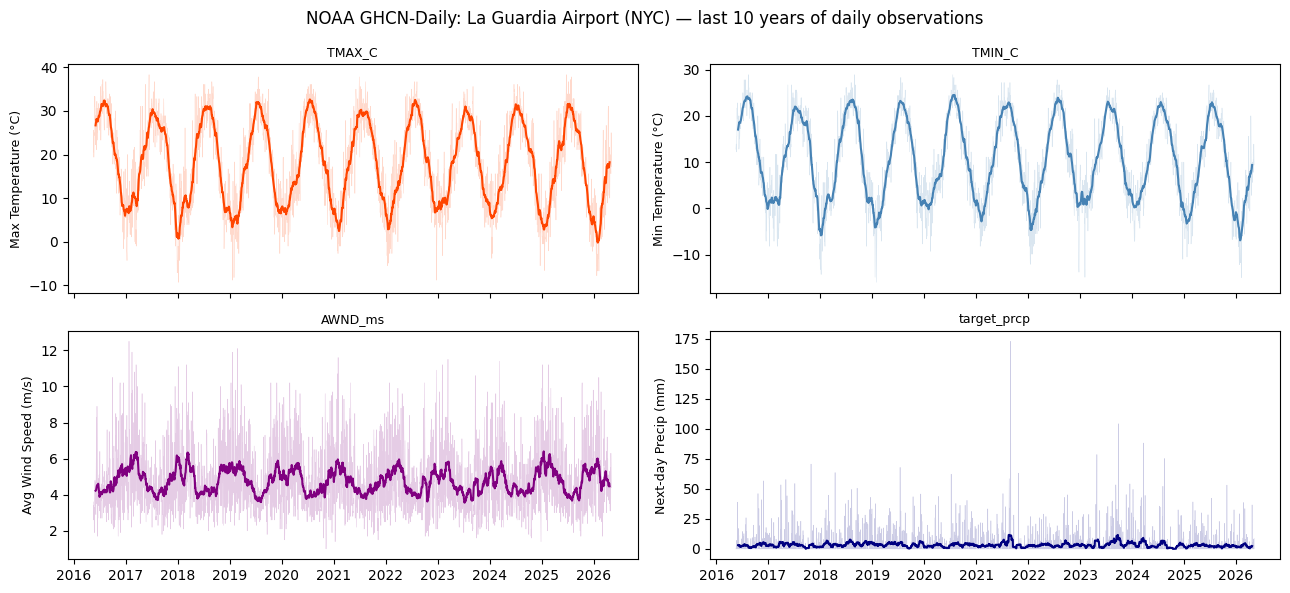

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
fig.suptitle(
    "NOAA GHCN-Daily: La Guardia Airport (NYC) — last 10 years of daily observations",
    fontsize=12,
)

plot_vars = [
    ("TMAX_C", "Max Temperature (°C)", "orangered"),
    ("TMIN_C", "Min Temperature (°C)", "steelblue"),
    ("AWND_ms", "Avg Wind Speed (m/s)", "purple"),
    ("target_prcp", "Next-day Precip (mm)", "navy"),
]

for ax, (col, ylabel, color) in zip(axes.flat, plot_vars, strict=False):
    monthly = df.set_index("DATE")[col].rolling(30, center=True).mean()
    ax.plot(df["DATE"], df[col], color=color, alpha=0.2, lw=0.4)
    ax.plot(df["DATE"], monthly, color=color, lw=1.5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

## Naive KFold: leakage from temporal autocorrelation

In [5]:
FEATURE_COLS = [
    "TMAX_C",
    "TMIN_C",
    "AWND_ms",
    "TRANGE_C",
    "TMIN_lag1",
    "TMAX_lag1",
    "PRCP_lag1",
    "PRCP_lag7",
]
X = df[FEATURE_COLS].values
y = df["target_prcp"].values

kf = KFold(n_splits=5, shuffle=False)
naive_r2 = []

for _fold_i, (train_idx, test_idx) in enumerate(kf.split(X)):
    pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    pipe.fit(X[train_idx], y[train_idx])
    r2 = pipe.score(X[test_idx], y[test_idx])
    naive_r2.append(r2)

print("Naive KFold R2 per fold:", [f"{r:.4f}" for r in naive_r2])
print(f"Naive KFold mean R2: {np.mean(naive_r2):.4f}")

Naive KFold R2 per fold: ['0.0005', '0.0173', '0.0144', '-0.0008', '-0.0087']
Naive KFold mean R2: 0.0045


## PurgedKFold: proper temporal holdout

`PurgedKFold(n_splits=5, purge_horizon="2D", embargo="1D")` removes the training rows next to each test fold so the label horizons cannot overlap it.

In [6]:
prediction_times = df["DATE"].reset_index(drop=True)
evaluation_times = prediction_times + pd.Timedelta(days=1)

cv = PurgedKFold(
    n_splits=5,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    purge_horizon="2D",
    embargo="1D",
)

temporal_r2 = []
for fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    pipe.fit(X[train_idx], y[train_idx])
    r2 = pipe.score(X[test_idx], y[test_idx])
    temporal_r2.append(r2)

    diagnostics.assert_no_temporal_leakage(
        train_idx,
        test_idx,
        prediction_times,
        evaluation_times,
        purge_horizon="2D",
    )
    print(
        f"  PurgedKFold fold {fold_i + 1}: R2={r2:.4f}, "
        f"train={len(train_idx)}, test={len(test_idx)} — no leakage ✓"
    )

print(f"\nPurgedKFold mean R2: {np.mean(temporal_r2):.4f}")

  PurgedKFold fold 1: R2=0.0006, train=2912, test=729 — no leakage ✓
  PurgedKFold fold 2: R2=0.0173, train=2910, test=729 — no leakage ✓
  PurgedKFold fold 3: R2=0.0143, train=2910, test=729 — no leakage ✓
  PurgedKFold fold 4: R2=-0.0008, train=2911, test=728 — no leakage ✓
  PurgedKFold fold 5: R2=-0.0087, train=2913, test=728 — no leakage ✓

PurgedKFold mean R2: 0.0045


## Comparison and overlap fraction

In [7]:
print("Overlap fraction (naive KFold):")
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X)):
    ovlp = diagnostics.compute_overlap_fraction(
        train_idx, test_idx, prediction_times, evaluation_times
    )
    print(f"  Fold {fold_i + 1}: {ovlp:.4f}")

print("\nOverlap fraction (PurgedKFold):")
for fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    ovlp = diagnostics.compute_overlap_fraction(
        train_idx, test_idx, prediction_times, evaluation_times
    )
    print(f"  Fold {fold_i + 1}: {ovlp:.4f}")

Overlap fraction (naive KFold):
  Fold 1: 0.0000
  Fold 2: 0.0000
  Fold 3: 0.0000
  Fold 4: 0.0000
  Fold 5: 0.0000

Overlap fraction (PurgedKFold):
  Fold 1: 0.0000
  Fold 2: 0.0000
  Fold 3: 0.0000
  Fold 4: 0.0000
  Fold 5: 0.0000


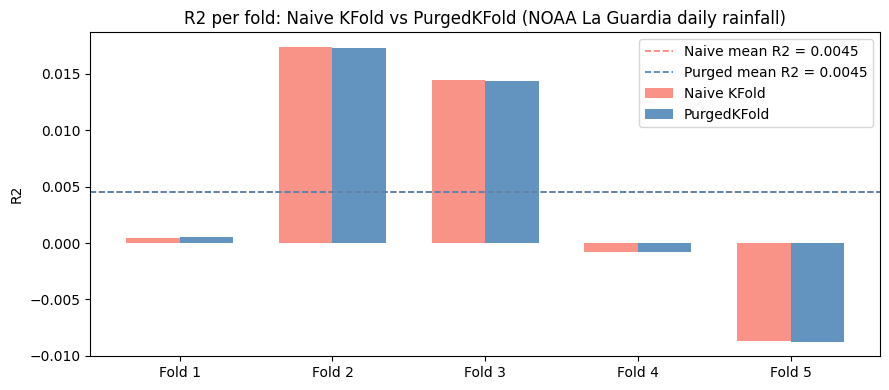

R2 inflation from naive splits: +0.0000


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

fold_labels = [f"Fold {i + 1}" for i in range(5)]
x = np.arange(5)
width = 0.35

ax.bar(x - width / 2, naive_r2, width, label="Naive KFold", color="salmon", alpha=0.85)
ax.bar(x + width / 2, temporal_r2, width, label="PurgedKFold", color="steelblue", alpha=0.85)
ax.axhline(
    np.mean(naive_r2),
    color="salmon",
    ls="--",
    lw=1.2,
    label=f"Naive mean R2 = {np.mean(naive_r2):.4f}",
)
ax.axhline(
    np.mean(temporal_r2),
    color="steelblue",
    ls="--",
    lw=1.2,
    label=f"Purged mean R2 = {np.mean(temporal_r2):.4f}",
)

ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel("R2")
ax.set_title("R2 per fold: Naive KFold vs PurgedKFold (NOAA La Guardia daily rainfall)")
ax.legend()
plt.tight_layout()
plt.show()

gap = np.mean(naive_r2) - np.mean(temporal_r2)
print(f"R2 inflation from naive splits: {gap:+.4f}")

## Conclusion

Daily rainfall is a case where temporal autocorrelation is both everywhere and physically real: today's weather genuinely constrains tomorrow's, and that constraint flows straight into a naive CV score.

`PurgedKFold` corrects for it by treating each 1-day label as a horizon that must not touch the test fold, with an embargo buffer for the residual lag.

**Data attribution:** NOAA Global Historical Climatology Network Daily (Menne et al., 2012). Station USW00014732 (La Guardia Airport, New York). Downloaded from https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/ — U.S. Government public domain data.